# 02 - Univariate EDA

            Mục tiêu:

            - Phân tích từng feature riêng lẻ.
            - Kiểm tra phân phối numeric.
            - Kiểm tra cardinality categorical.
            - Phát hiện skew/outlier/missing.

In [17]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: e:\fraud-detection-project


In [18]:
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "data" / "reports"

candidate_paths = [
    INTERIM_DIR / "fraud_cleaned.parquet",
    PROCESSED_DIR / "cleaned_data.parquet",
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raw_csvs = list((PROJECT_ROOT / "data" / "raw").glob("*.csv"))
    if not raw_csvs:
        raise FileNotFoundError("Không tìm thấy dữ liệu cleaned hoặc raw csv.")
    DATA_PATH = raw_csvs[0]

print("Using:", DATA_PATH)

if DATA_PATH.suffix == ".parquet":
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

df.head()

Using: e:\fraud-detection-project\data\interim\fraud_cleaned.parquet


,amount,currency,local_timestamp,payment_channel,merchant_country,mcc,card_present,ip_risk,device_id,card_entry_mode,auth_result,merchant_id,pin_verif_method,tokenised,recurring_flag,cross_border,card_activation_age,auth_characteristics,message_type,mean_amount_30d,std_amount_30d,max_amount_30d,txn_counts,distinct_merchants_7d,distinct_countries_30d,online_share_7d,night_ratio_30d,days_since_last_txn,decline_rate_30d,chargebacks_365d,device_diversity_30d,mcc_entropy_30d,credit_util_today,spending_trend,term_location,fraud,ip_address,ip_score,txn_count_7d,txn_count_30d,txn_count_ratio_7d_30d,ip_is_private,ip_score_bin,transaction_datetime,hour,day_of_week,day_name,is_weekend,is_night_txn,month,day,year,time_period,night_unusual_score,is_night_unusual,amount_invalid_flag,std_amount_30d_zero_flag,mean_amount_30d_zero_flag,duplicate_row_flag
0,100606.12,USD,2025-03-19 10:23:03,ATM,PH,7736,True,"{'ip': '190.3.86.171', 'score': 0.1467}",DEV-7726FB1A8A274C4B,CHIP,3DS_FAIL,MID-2585C551D674,OFFLINE_PIN,False,MOTO_PHONE,True,4282,FALLBACK_MAG,0110-AuthRsp,5.19,6.62,34046.16,"(13, 21)",112,2,0.210,0.084,100,0.271,3,27,0.801,0.943,1.460,BRANCH_COUNTER,0,190.3.86.171,0.1467,13.0,21.0,0.590909,0,low,2025-03-19 10:23:03,10,2,Wednesday,0,0,3,19,2025,morning,0.000,0,0,0,0,0
1,146953.67,USD,2025-05-16 00:35:42,WEB_BROWSER,GB,3242,False,"{'ip': '79.201.116.230', 'score': 0.5243}",DEV-68CD2988A8C345AC,CHIP,BIOMETRIC_PASS,MID-CA3988467DD9,ONLINE_PIN,True,INSTALLMENT_PLAN,False,3804,CRYPTOGRAM_PRESENT,0110-AuthRsp,6.18,35.50,7146.37,"(22, 256)",3,9,0.665,0.751,177,0.098,3,17,0.651,1.269,4.980,BRANCH_COUNTER,0,79.201.116.230,0.5243,22.0,256.0,0.085603,0,high,2025-05-16 00:35:42,0,4,Friday,0,1,5,16,2025,night,0.249,0,0,0,0,0
2,161096.38,USD,2025-04-10 03:03:24,ATM,US,5638,True,"{'ip': '16.247.34.115', 'score': 0.4811}",DEV-C75EBE4E1BCB4362,TOKEN_IN_APP,CVV_FAIL,MID-9D430F327DF7,OFFLINE_PIN,True,RECURRING_SUBSCRIPTION,False,2292,E_COMMERCE,0110-AuthRsp,5.80,4.32,72447.86,"(13, 29)",40,16,0.322,0.637,34,0.092,0,11,0.646,0.291,4.514,KIOSK,0,16.247.34.115,0.4811,13.0,29.0,0.433333,0,medium,2025-04-10 03:03:24,3,3,Thursday,0,1,4,10,2025,night,0.363,0,0,0,0,0
3,131491.00,CNY,2025-03-28 02:39:22,MOBILE_APP,JP,7800,False,"{'ip': '23.130.177.181', 'score': 0.3218}",DEV-DFE8A6350785435B,MAGSTRIPE,3DS_PASS,MID-6E0F7E9155DB,OFFLINE_PIN,False,MOTO_PHONE,False,2711,E_COMMERCE,0420-RepeatRev,5.29,3.84,228799.51,"(58, 375)",21,3,0.233,0.497,132,0.055,0,23,1.638,1.202,1.316,CALL_CENTER,0,23.130.177.181,0.3218,58.0,375.0,0.154255,0,medium,2025-03-28 02:39:22,2,4,Friday,0,1,3,28,2025,night,0.503,0,0,0,0,0
4,71265.99,CNY,2025-05-18 12:14:09,SMART_WATCH,PH,5789,False,"{'ip': '9.44.12.213', 'score': 0.1168}",DEV-07B9EB6E54CC459C,CHIP,CVV_FAIL,MID-0C99A14622F8,ONLINE_PIN,False,MOTO_MAIL,False,2845,CARD_PRESENT,0110-AuthRsp,6.69,1.82,108426.28,"(60, 266)",100,6,0.909,0.831,162,0.201,0,16,2.033,1.846,3.805,POS_TERMINAL,0,9.44.12.213,0.1168,60.0,266.0,0.224719,0,low,2025-05-18 12:14:09,12,6,Sunday,1,0,5,18,2025,afternoon,0.000,0,0,0,0,0


In [19]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 36
Categorical columns: 22


C:\Users\HungT\AppData\Local\Temp\ipykernel_9700\1448632789.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [20]:
numeric_summary = df[numeric_cols].describe().T
numeric_summary["missing_rate"] = df[numeric_cols].isna().mean()
numeric_summary["skew"] = df[numeric_cols].skew(numeric_only=True)
display(numeric_summary.sort_values("missing_rate", ascending=False).head(50))

,count,mean,std,min,25%,50%,75%,max,missing_rate,skew
amount,100000.0,100258.956341,57846.453927,1.4300,50047.350000,100477.090000,150467.410000,199999.750000,0.0,-0.004959
mcc,100000.0,5174.558360,1599.107713,3000.0000,4004.000000,5003.000000,7003.000000,7999.000000,0.0,0.297379
card_activation_age,100000.0,2190.514850,1265.481956,0.0000,1090.000000,2192.000000,3285.000000,4380.000000,0.0,-0.003453
mean_amount_30d,100000.0,7.621799,3.361832,5.0000,5.610000,6.550000,8.350000,97.990000,0.0,4.039841
std_amount_30d,100000.0,2.449265,1.952187,1.0000,1.330000,1.830000,2.820000,42.970000,0.0,4.532139
max_amount_30d,100000.0,125015.089751,72304.578120,51.5900,62199.860000,124744.115000,187785.087500,249999.110000,0.0,0.000500
distinct_merchants_7d,100000.0,60.634930,34.697668,1.0000,31.000000,60.000000,91.000000,120.000000,0.0,0.001164
distinct_countries_30d,100000.0,12.992210,7.219368,1.0000,7.000000,13.000000,19.000000,25.000000,0.0,-0.001667
online_share_7d,100000.0,0.499554,0.289268,0.0000,0.249000,0.500000,0.750000,1.000000,0.0,0.006401
night_ratio_30d,100000.0,0.499404,0.288221,0.0000,0.251000,0.498000,0.749000,1.000000,0.0,0.003876


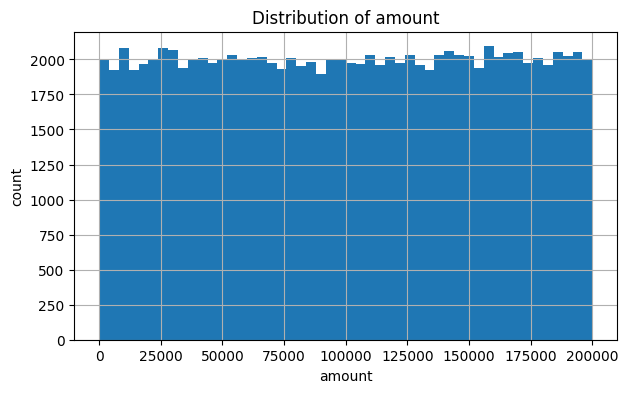

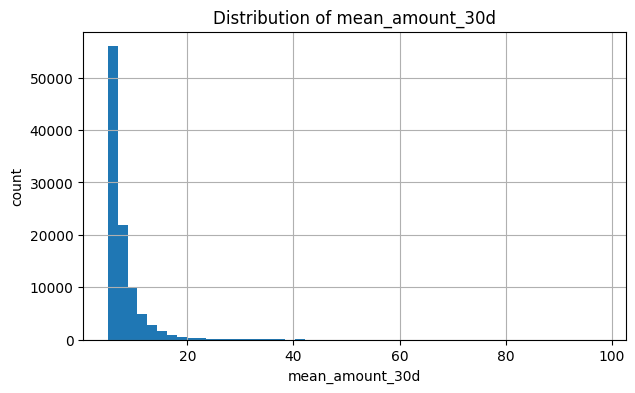

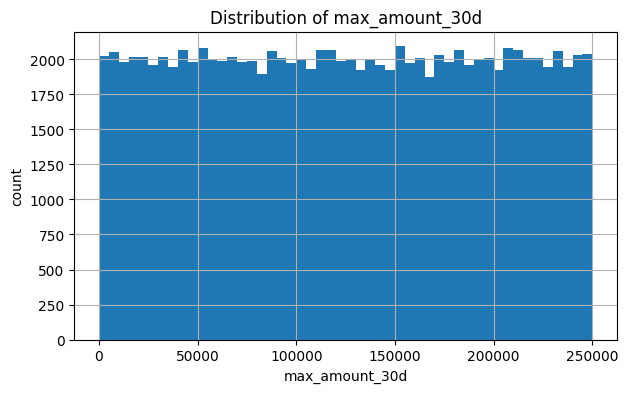

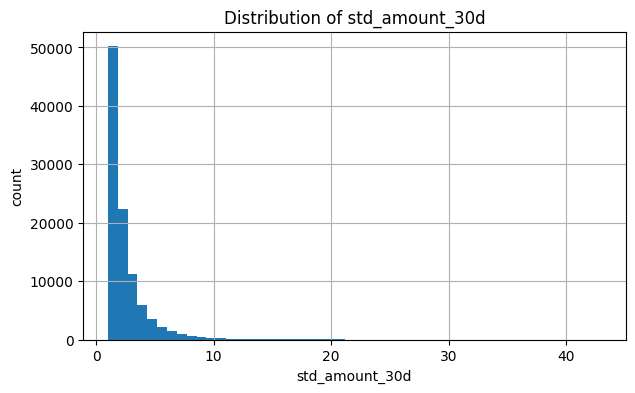

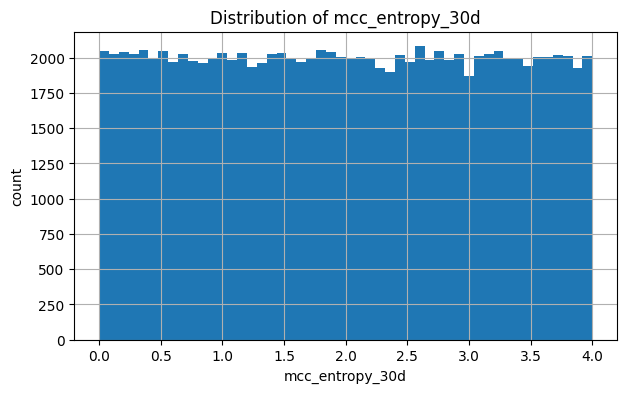

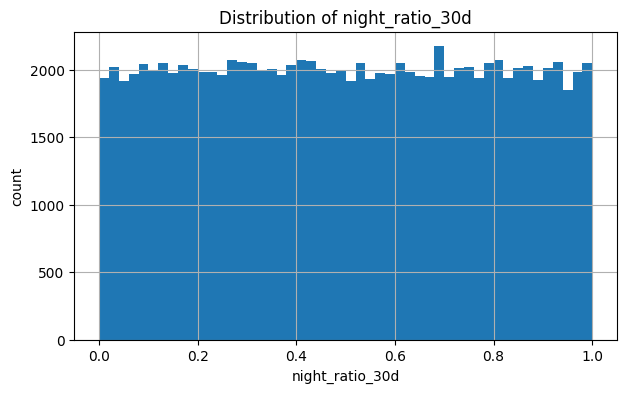

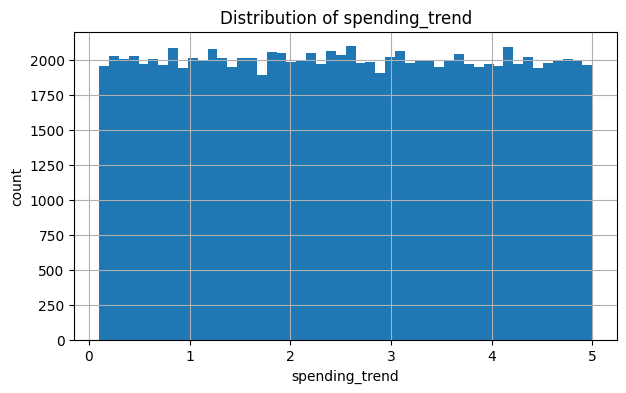

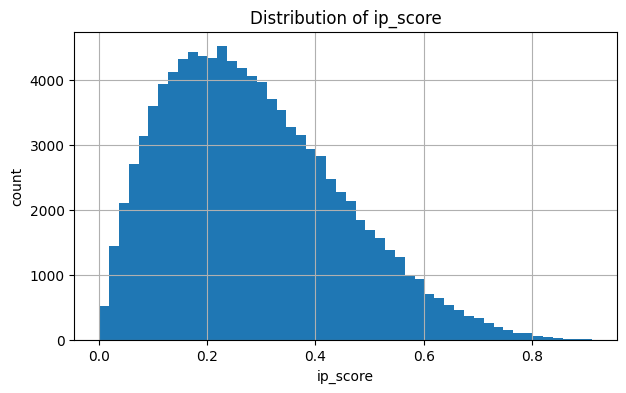

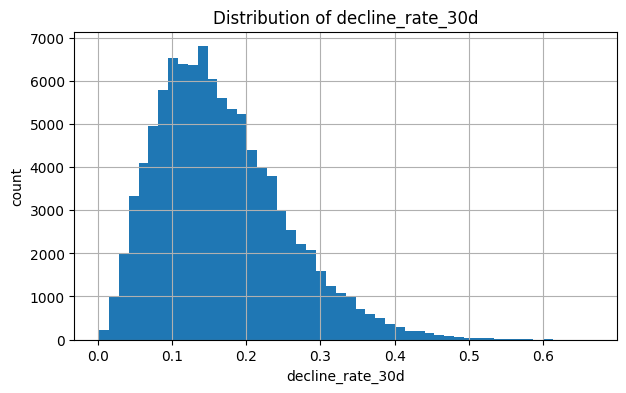

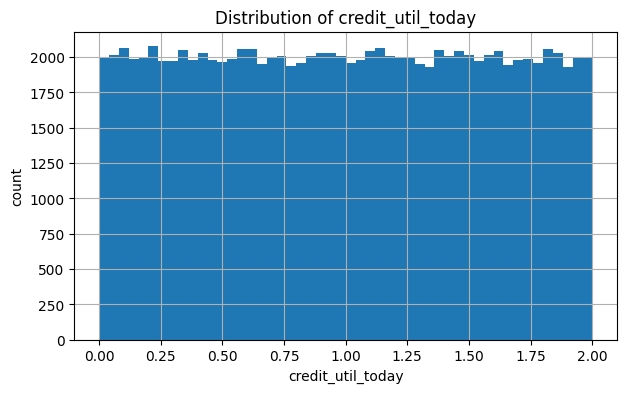

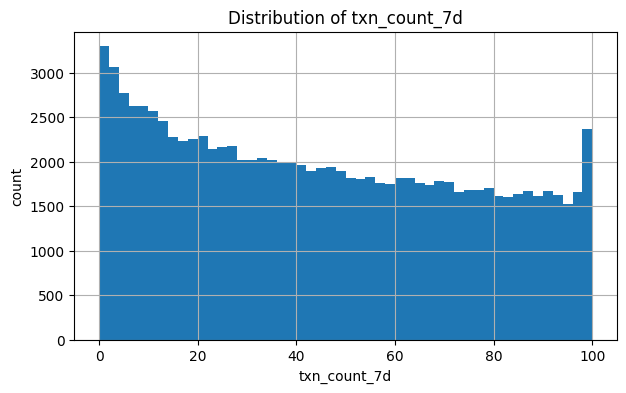

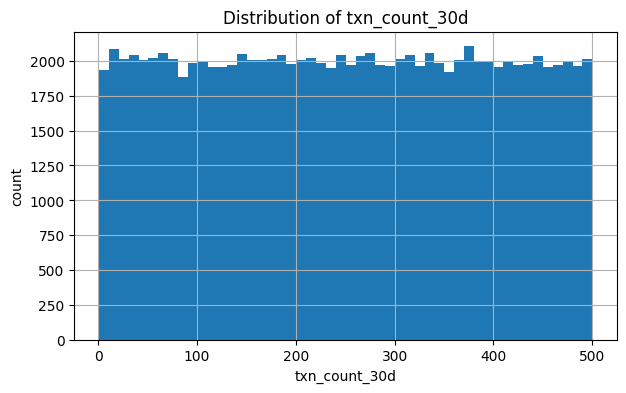

In [21]:
important_numeric = [
    "amount",
    "mean_amount_30d",
    "max_amount_30d",
    "std_amount_30d",
    "mcc_entropy_30d",
    "night_ratio_30d",
    "spending_trend",
    "ip_score",
    "decline_rate_30d",
    "credit_util_today",
    "txn_count_7d",
    "txn_count_30d",
]

for col in important_numeric:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        df[col].dropna().hist(bins=50)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.show()

In [22]:
cardinality = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [df[c].nunique(dropna=True) for c in categorical_cols],
    "missing_rate": [df[c].isna().mean() for c in categorical_cols],
}).sort_values("n_unique", ascending=False)

display(cardinality)

,column,n_unique,missing_rate
5,ip_risk,100000,0.0
6,device_id,100000,0.0
9,merchant_id,100000,0.0
18,ip_address,99998,0.0
1,local_timestamp,99371,0.0
16,txn_counts,39665,0.0
3,merchant_country,20,0.0
0,currency,15,0.0
8,auth_result,8,0.0
15,message_type,8,0.0


In [23]:
for col in categorical_cols[:30]:
    print("\n" + "=" * 100)
    print(col)
    display(df[col].astype(str).value_counts(dropna=False).head(20))


currency


currency
USD    38201
EUR    14257
GBP     7566
JPY     5624
CNY     4816
THB     3921
CHF     2942
SGD     2894
KRW     2868
AUD     2851
INR     2838
VND     2832
HKD     2827
CAD     2786
IDR     2777
Name: count, dtype: int64


local_timestamp


local_timestamp
2025-04-16 11:34:00    3
2025-03-14 08:14:56    3
2025-04-15 00:47:27    2
2025-05-24 23:13:14    2
2025-03-16 00:05:35    2
2025-03-24 22:11:43    2
2025-03-28 02:42:48    2
2025-04-02 16:44:35    2
2025-05-04 02:00:06    2
2025-03-13 08:49:16    2
2025-03-31 10:07:20    2
2025-05-04 02:49:28    2
2025-05-29 16:19:41    2
2025-05-24 01:14:12    2
2025-04-20 11:18:05    2
2025-05-02 12:01:52    2
2025-04-16 14:58:17    2
2025-05-10 21:55:20    2
2025-06-01 07:33:12    2
2025-04-20 04:11:07    2
Name: count, dtype: int64


payment_channel


...

ip_score_bin
medium       54536
low          34416
high         10902
very_high      146
Name: count, dtype: int64


day_name


day_name
Saturday     14554
Tuesday      14547
Sunday       14510
Wednesday    14319
Monday       14311
Friday       13939
Thursday     13820
Name: count, dtype: int64


time_period


time_period
morning         25198
afternoon       24895
night           24790
evening         16672
late_evening     8445
Name: count, dtype: int64

In [24]:
# Đọc report EDA nếu có
for file in [
    "numeric_summary.csv",
    "categorical_summary.csv",
    "missing_report.csv",
    "high_cardinality_report.csv",
]:
    path = REPORT_DIR / file
    if path.exists():
        print("\n" + "=" * 100)
        print(file)
        display(pd.read_csv(path).head(30))


numeric_summary.csv


,column,count,mean,std,min,25%,50%,75%,max,missing_count,missing_rate,skewness
0,amount,100000.0,100258.956341,57846.453927,1.430,50047.350,100477.0900,150467.4100,199999.750,0,0.0,-0.004959
1,mcc,100000.0,5174.558360,1599.107713,3000.000,4004.000,5003.0000,7003.0000,7999.000,0,0.0,0.297379
2,card_activation_age,100000.0,2190.514850,1265.481956,0.000,1090.000,2192.0000,3285.0000,4380.000,0,0.0,-0.003453
3,mean_amount_30d,100000.0,7.621799,3.361832,5.000,5.610,6.5500,8.3500,97.990,0,0.0,4.039841
4,std_amount_30d,100000.0,2.449265,1.952187,1.000,1.330,1.8300,2.8200,42.970,0,0.0,4.532139
5,max_amount_30d,100000.0,125015.089751,72304.578120,51.590,62199.860,124744.1150,187785.0875,249999.110,0,0.0,0.000500
6,distinct_merchants_7d,100000.0,60.634930,34.697668,1.000,31.000,60.0000,91.0000,120.000,0,0.0,0.001164
7,distinct_countries_30d,100000.0,12.992210,7.219368,1.000,7.000,13.0000,19.0000,25.000,0,0.0,-0.001667
8,online_share_7d,100000.0,0.499554,0.289268,0.000,0.249,0.5000,0.7500,1.000,0,0.0,0.006401
9,night_ratio_30d,100000.0,0.499404,0.288221,0.000,0.251,0.4980,0.7490,1.000,0,0.0,0.003876



categorical_summary.csv


,column,dtype,unique_count,missing_count,missing_rate,top_values
0,currency,str,15,0,0.0,USD: 38201; EUR: 14257; GBP: 7566; JPY: 5624; ...
1,local_timestamp,str,99371,0,0.0,2025-04-16 11:34:00: 3; 2025-03-14 08:14:56: 3...
2,payment_channel,str,7,0,0.0,WEB_BROWSER: 14469; API_SERVER: 14407; SMART_W...
3,merchant_country,str,20,0,0.0,BR: 5145; AU: 5089; ZA: 5088; KR: 5072; VN: 50...
4,card_present,bool,2,0,0.0,False: 65166; True: 34834
5,ip_risk,str,100000,0,0.0,"{'ip': '190.3.86.171', 'score': 0.1467}: 1; {'..."
6,device_id,str,100000,0,0.0,DEV-7726FB1A8A274C4B: 1; DEV-68CD2988A8C345AC:...
7,card_entry_mode,str,6,0,0.0,CHIP: 16857; MANUAL_KEYED: 16780; QR_CODE: 166...
8,auth_result,str,8,0,0.0,CVV_PASS: 12725; AVS_FAIL: 12698; CVV_FAIL: 12...
9,merchant_id,str,100000,0,0.0,MID-2585C551D674: 1; MID-CA3988467DD9: 1; MID-...



missing_report.csv


,column,missing_count,missing_rate,non_missing_count
0,amount,0,0.0,100000
1,currency,0,0.0,100000
2,local_timestamp,0,0.0,100000
3,payment_channel,0,0.0,100000
4,merchant_country,0,0.0,100000
5,mcc,0,0.0,100000
6,card_present,0,0.0,100000
7,ip_risk,0,0.0,100000
8,device_id,0,0.0,100000
9,card_entry_mode,0,0.0,100000



high_cardinality_report.csv


,column,dtype,unique_count,unique_rate,note
0,amount,float64,99765,0.99765,High cardinality - không nên one-hot trực tiếp
1,local_timestamp,str,99371,0.99371,High cardinality - không nên one-hot trực tiếp
2,mcc,int64,3351,0.03351,High cardinality - không nên one-hot trực tiếp
3,ip_risk,str,100000,1.00000,High cardinality - không nên one-hot trực tiếp
4,device_id,str,100000,1.00000,High cardinality - không nên one-hot trực tiếp
5,merchant_id,str,100000,1.00000,High cardinality - không nên one-hot trực tiếp
6,card_activation_age,int64,4381,0.04381,High cardinality - không nên one-hot trực tiếp
7,mean_amount_30d,float64,2252,0.02252,High cardinality - không nên one-hot trực tiếp
8,std_amount_30d,float64,1494,0.01494,High cardinality - không nên one-hot trực tiếp
9,max_amount_30d,float64,99827,0.99827,High cardinality - không nên one-hot trực tiếp


## Kết luận cần ghi sau khi chạy

            - Feature numeric nào skew mạnh?
            - Feature nào có outlier?
            - Categorical nào nhiều giá trị hiếm?
            - Cột nào nên log/bin/group rare category?